In [76]:
import sys
if "vision_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [77]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import cv2

print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.2.5


<font color = #000000 >

## 9. 案例1:银行卡数字识别
</font>


In [78]:
picture = './Pictures/'
# 定义图像展示函数
def img_show(img):
    if img is None:
        print("图像读取失败")
    else:
        # 图像展示
        cv2.imshow("image", img)    # 首先需要确定图像存在才能打开
        print("img.shape = " , img.shape)
        cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键
        cv2.destroyAllWindows() 

<font color = #000000>

### 9-1 数字模版轮廓检测


</font>

In [79]:
# 1. 前提: 图像读取
def read_img(path, flag=cv2.IMREAD_COLOR):
    img = cv2.imread(path, flag)
    if img is None:
        raise FileNotFoundError(f"图像读取失败: {path}")
    else:
        print('图像读取成功, shape:' , img.shape)
    return img

# 得到灰度图像
img = read_img(picture + "ocr_a_reference.png" , cv2.IMREAD_GRAYSCALE)


图像读取成功, shape: (126, 800)


len(contours) =  10


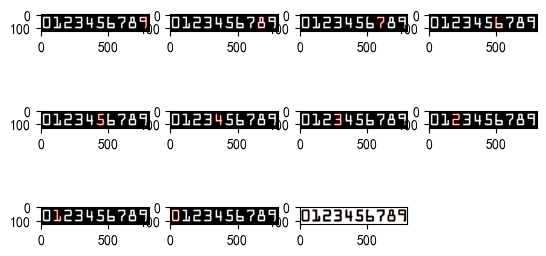

In [80]:
# 2. 二值化处理
_ , thresh = cv2.threshold(img.copy(), 127, 255, cv2.THRESH_BINARY_INV) # 最好是白色部分为被检测区
# 3. 轮廓检测:RETR_EXTERNAL:只检测外轮廓
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
print('len(contours) = ' , len(contours))
# 观察一下,画布需要支持颜色,所以灰度转RGB
img_background = cv2.cvtColor(thresh , cv2.COLOR_GRAY2RGB)
for i in range(len(contours)):
    plt.subplot(4,4,i+1)    # !!!原图需要copy!!!,否则就是直接在原图上作画,影响后续实验
    plt.imshow(cv2.drawContours(img_background.copy(), contours,  i , (255, 0, 0), 2))
plt.subplot(4,4,len(contours) + 1) 
plt.imshow(cv2.drawContours(img.copy(), contours, -1, (0, 0, 255), 4) , 'hot')

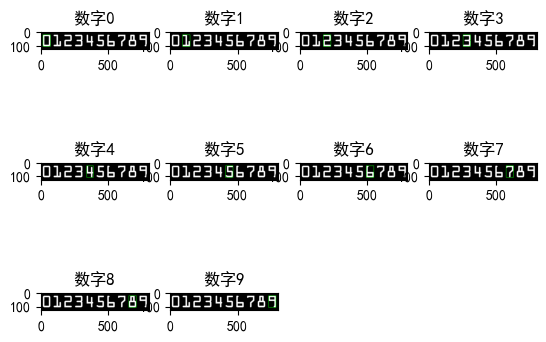

In [81]:
# 3. 提取出矩形
# 3-1 首先遍历得到所有的x,y,w,h
num_list = []   # 创建一个字模列表,收录:x,y,w,h字典
for i , cnt in enumerate(contours):
    x, y , w , h = cv2.boundingRect(cnt)
    # x,y,w,h属性收录到字典中
    num_list.append({
        "x" : x,
        "y" : y,
        "w" : w,
        "h" : h,
        "img": thresh[y:y+h , x:x+w]    # 在 NumPy / OpenCV 图像数组中，索引顺序是：img[y, x]
    })
    num_list[i]['img'] = cv2.resize(num_list[i]['img'], (57, 88))   # 字模尺寸变成相同的,后续好处理
# 3-2 根据字模的x属性进行排序,得到字模列表
num_list = sorted(num_list, key=lambda x: x["x"] , reverse=False)
# 3-3 看看具体字模效果
for i in range(10):
    rect_img = img_background.copy()  # 每次都拷贝
    plt.subplot(3,4,i+1)
    plt.imshow(cv2.rectangle(rect_img , (num_list[i]['x'] , num_list[i]['y']) , 
                             (num_list[i]['x'] + num_list[i]['w'] , 
                              num_list[i]['y'] + num_list[i]['h']) , (0,255,0) , 2) , 'gray')
    plt.title(f'数字{i}')

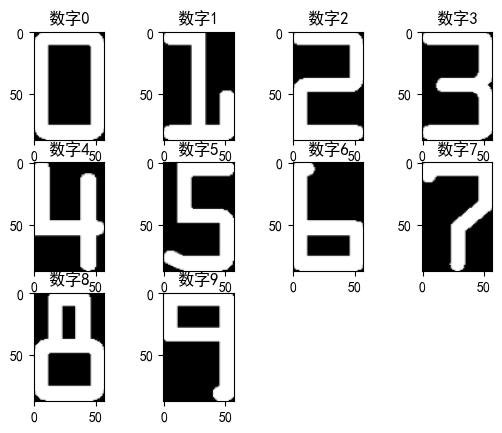

In [82]:
# 3-4 展示字模图片
for i in range(10):
    plt.subplot(3,4,i+1)
    plt.imshow(num_list[i]['img'] , 'gray')
    plt.title(f'数字{i}')

<font color = #000000>

### 9-2 输入数据预处理 


</font>

In [83]:
# 对img进行等宽高缩放处理函数
def img_resize_wh_keep_ratio(img, width=0, height=0):
    h, w = img.shape[:2]

    if width == 0 and height == 0:
        return img

    # 计算缩放比例
    if width == 0:
        scale = height / h
        new_w = int(w * scale)
        new_h = height
    elif height == 0:
        scale = width / w
        new_w = width
        new_h = int(h * scale)
    else:
        scale = min(width / w, height / h)
        new_w = int(w * scale)
        new_h = int(h * scale)

    # 等比例缩放
    resized = cv2.resize(img, (new_w, new_h))

    # 如果只指定一边，直接返回缩放后的图像
    if width == 0 or height == 0:
        return resized

    # 两边都指定 → 创建黑色画布
    canvas = np.zeros((height, width), dtype=img.dtype)

    start_x = (width - new_w) // 2
    start_y = (height - new_h) // 2
    canvas[start_y:start_y+new_h, start_x:start_x+new_w] = resized

    return canvas

图像读取成功, shape: (368, 583)
(368, 583)


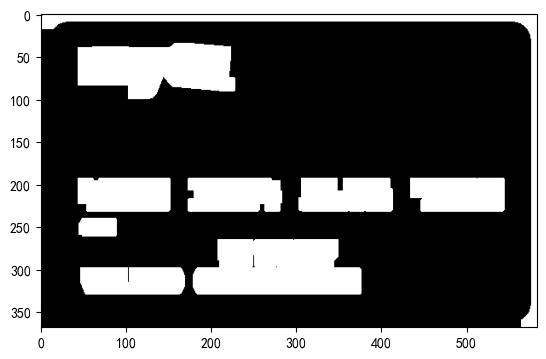

In [84]:
# 1. 读取银行卡
img = read_img(picture + 'credit_card_01.png' , cv2.IMREAD_GRAYSCALE)
# img = img_resize_wh_keep_ratio(img , height=300)
print(img.shape)
# 2. 二值化处理,过滤掉无用背景
_ , thresh = cv2.threshold(img , 127 , 255 , cv2.THRESH_BINARY)
img_background = cv2.cvtColor(img , cv2.COLOR_GRAY2RGB) # 背景颜色
# 3. 将当前白色区域相邻的连在一起成为区块:使用闭操作:先膨胀再腐蚀,得到近似的模糊区块
kernel = np.ones((10,10) , np.uint8)
closing = cv2.morphologyEx(thresh , cv2.MORPH_CLOSE , kernel) 
# 4. 膨胀操作,使得区块之间进一步连接
kernel = np.ones((5,6),np.uint8) 
closing = cv2.dilate(closing,kernel,iterations = 3)    # 基于上次腐蚀得到的图像进行膨胀
plt.imshow(closing , 'gray')

len(contours) =  9


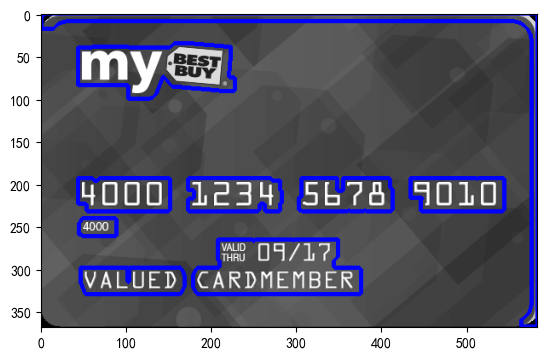

In [85]:
# 5. 检测轮廓
contours , _ = cv2.findContours(closing.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# 6. 可视化所有轮廓
ret = cv2.drawContours(img_background.copy(), contours, -1, (0, 0, 255), 3)
plt.imshow(ret , 'gray')
print('len(contours) = ' , len(contours))

[(43, 193, 109, 40),
 (172, 193, 111, 40),
 (302, 193, 111, 40),
 (433, 193, 111, 40)]

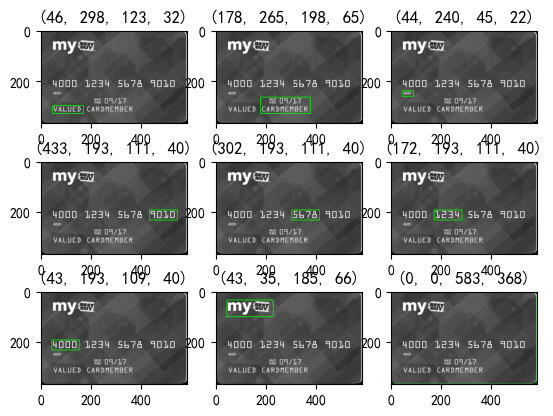

In [86]:
# 7. 筛选轮廓(根据银行卡的宽高比进行筛选)
target_num_list = []  # 目标银行卡区块
for i , cnt in enumerate(contours):
    x,y,w,h = cv2.boundingRect(cnt)
    # 进行宽高比对照,得到目标区块   
    rect_img = img_background.copy()  # 每次都拷贝
    plt.subplot(3,3,i+1)
    plt.imshow(cv2.rectangle(rect_img ,(x,y) ,(x+w , y+h), (0,255,0) , 2) , 'gray')
    plt.title(f'{x,y,w,h}')
    # 开始正式筛选
    if 2.5 < w / float(h) < 4.0:  # 银行卡号区域的典型宽高比
        if (100 < w < 120) and (30 < h < 60):  # 尺寸范围
            target_num_list.append((x, y, w, h))
# 按x坐标排序（从左到右）
target_num_list = sorted(target_num_list, key=lambda x: x[0])
# 得到所需轮廓
target_num_list


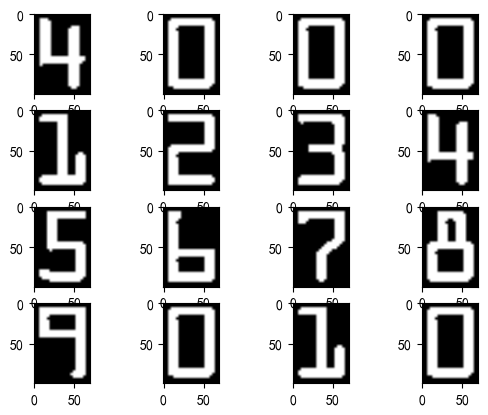

In [87]:
# 8. 轮廓数据转变存储:一共4*4 = 16个数据
id_list_img = []
for (x,y,w,h) in target_num_list:
    # 这里得到了单个数据组,一共4个数据,都需要存入num_group
    # 8-1 数据组提取
    group = thresh[y-5:y+h+5 , x-5:x+w+5]
    group_bg = cv2.cvtColor(group.copy() , cv2.COLOR_GRAY2RGB)
    # 8-2 轮廓提取(外轮廓)
    contours , _ = cv2.findContours(group.copy() , cv2.RETR_EXTERNAL , cv2.CHAIN_APPROX_NONE)
    # ret = cv2.drawContours(group_bg.copy() , contours , -1 , (0,0,255) , 1)
    # img_show(ret)
    # 8-3 矩形提取,存入id_list_img_group列表中
    id_list_img_group = []
    for i , cnt in enumerate(contours) : 
        x, y , w , h = cv2.boundingRect(cnt)
        id_list_img_group.append({
            'x':x,
            'y':y,
            'w':w,
            'h':h,
            'img':group[y-2:y+h+2, x-2:x+w+2]
        })
        # resize操作
        id_list_img_group[i]['img'] = cv2.resize(id_list_img_group[i]['img'] , (70, 100))
    # 8-4 矩形列表排序
    id_list_img_group = sorted(id_list_img_group, key=lambda x: x['x'])
    # 8-5 存入到总id表中
    id_list_img.extend(id_list_img_group)

# 8-6 绘图
for (i,id_img) in enumerate(id_list_img):
    plt.subplot(4,4,i+1)
    plt.imshow(id_img['img'] , 'gray')


<font color = #000000>

### 9-3 数据识别算法


</font>

In [88]:
# 模版匹配
id = []
for (i,id_img) in enumerate(id_list_img):
    scores = []
    for x in num_list:
        # ret = np.hstack((id_img['img'] , x['img']))
        # img_show(ret)
        result = cv2.matchTemplate(id_img['img'] , x['img'] , cv2.TM_CCOEFF)
        _ , max_val, _ , _ = cv2.minMaxLoc(result)
        scores.append(max_val)  # 得到该字模的评分
        # print(max_val)
    id.append(np.argmax(scores))    # 得到该字模的最可能出现的概率数字
id

[np.int64(4),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(0),
 np.int64(1),
 np.int64(0)]